In [ ]:
install.packages("dplyr")

In [1]:
library(dplyr)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [9]:
df = read.delim("sort_curated_all_peterplot_data.csv", header = TRUE, stringsAsFactors = FALSE, quote = "", sep = "\t",fileEncoding="UTF-16LE")

In [34]:
head(df)
library(tidyr)
#df_mod <- df[df$raw_alinged=='aligned' & df_mod$collapsed=='aligned',]

# Remove rows with missing data for any of the variables we need
df_mod <- df %>% drop_na(strains, 	timpepoint	, replicate, length, U, A, C, G)


collapsed,F7,F7...Split.2,F7...Split.2...Split.1,F7...Split.2...Split.2,F7...Split.2...Split.3,F7...Split.2...Split.3...Split.2,F7...Split.2...Split.3...Split.3,F7...Split.2...Split.3...Split.6,raw_alinged,replicate,strains,timpepoint,A,C,G,length,N,U
aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,,aligned,1,129S1_SvImJ,12.5dpp,0.000000000,0.000000000,0.000000000,19,0.000000e+00,0.000000000
aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,,aligned,1,129S1_SvImJ,12.5dpp,0.001018490,0.000468701,0.001672483,20,7.616557e-06,0.001757097
aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,,aligned,1,129S1_SvImJ,12.5dpp,0.000776822,0.003856739,0.002882418,21,1.643048e-05,0.002339979
aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,,aligned,1,129S1_SvImJ,12.5dpp,0.001045530,0.000838387,0.002570838,22,1.460117e-05,0.005362821
aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,,aligned,1,129S1_SvImJ,12.5dpp,0.001198494,0.001069977,0.009707053,23,2.235077e-05,0.006488243
aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,,aligned,1,129S1_SvImJ,12.5dpp,0.002071105,0.001144812,0.029348691,24,7.416997e-05,0.012448149


In [28]:
library(ggridges)

# Create a stacked bar plot for each strain
my_plot <- df_mod %>%
  ggplot(aes(x = length, y = strains, fill = U)) +
  geom_col(aes(y = A), position = position_stack(reverse = TRUE), color = "black") +
  geom_col(aes(y = C), position = position_stack(reverse = TRUE), color = "green") +
  geom_col(aes(y = G), position = position_stack(reverse = TRUE), color = "blue") +
  geom_col(aes(y = U), position = position_stack(reverse = TRUE), color = "red") +
  scale_fill_gradient(low = "white", high = "blue") +
  labs(x = "Length", y = "Strains", fill = "U") +
  theme_minimal()



In [29]:
# Add facetting by timepoint and replicate, using the filtered data
my_plot_with_facets <- my_plot +
  facet_grid(replicate ~ timpepoint, drop = TRUE)



In [30]:
# Check if any facets were dropped due to missing data
dropped_facets <- unique(df_mod[, c("replicate", "timpepoint")]) %>% 
  anti_join(unique(df_mod[, c("replicate", "timpepoint")]) ,
            by = c("replicate", "timpepoint"))



In [31]:
if (nrow(dropped_facets) > 0) {
  cat("The following combinations of timepoint and replicate were dropped due to missing data:\n")
  print(dropped_facets)
}

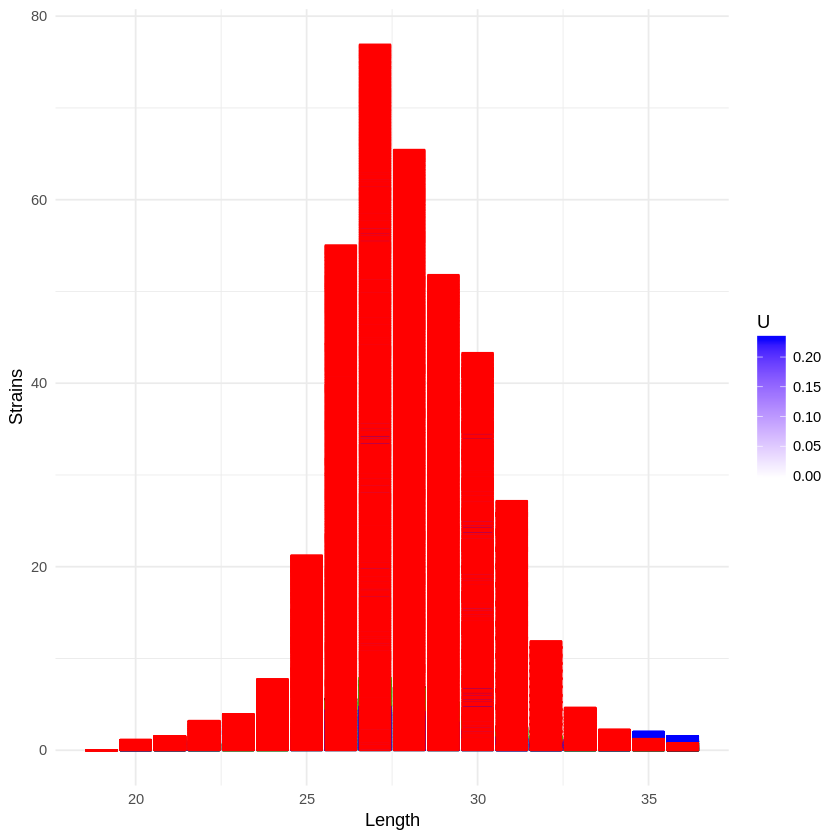

In [32]:
# Display plot in notebook
print(my_plot)

Picking joint bandwidth of 2
Picking joint bandwidth of 2
Picking joint bandwidth of 2
Picking joint bandwidth of 2
Picking joint bandwidth of 2
Picking joint bandwidth of 2
Picking joint bandwidth of 2
Picking joint bandwidth of 2
Picking joint bandwidth of 2


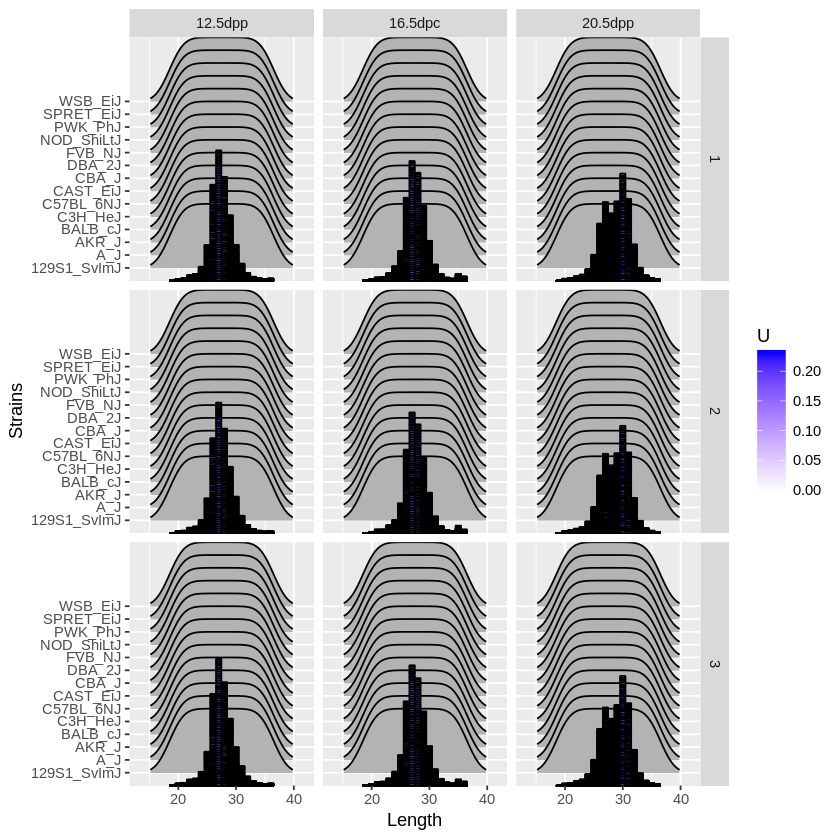

In [43]:
library(ggridges)

df_mod %>%
  ggplot(aes(x = length, y = strains, fill = U)) +
  geom_density_ridges_gradient(scale = 5, rel_min_height = 0.05) +
  geom_col(aes(y = A), position = position_stack(reverse = TRUE), color = "black") +
  geom_col(aes(y = C), position = position_stack(reverse = TRUE), color = "black") +
  geom_col(aes(y = G), position = position_stack(reverse = TRUE), color = "black") +
  geom_col(aes(y = U), position = position_stack(reverse = TRUE), color = "black") +
  facet_grid(replicate~timpepoint) +
  scale_fill_gradient(low = "white", high = "blue") +
  labs(x = "Length", y = "Strains", fill = "U") 


In [27]:
df = pd.read_csv("sort_curated_all_peterplot_data.csv",sep="\t", encoding = 'utf-16')
df = df[df.collapsed  == 'aligned']
df = df[df.raw_alinged  == 'aligned']
df.head()

,collapsed,F7,F7 - Split 2,F7 - Split 2 - Split 1,F7 - Split 2 - Split 2,F7 - Split 2 - Split 3,F7 - Split 2 - Split 3 - Split 2,F7 - Split 2 - Split 3 - Split 3,F7 - Split 2 - Split 3 - Split 6,raw_alinged,replicate,strains,timpepoint,A,C,G,length,N,U
0,aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,NaN,aligned,1,129S1_SvImJ,12.5dpp,0.000000,0.000000,0.000000,19,0.000000,0.000000
1,aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,NaN,aligned,1,129S1_SvImJ,12.5dpp,0.001018,0.000469,0.001672,20,0.000008,0.001757
2,aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,NaN,aligned,1,129S1_SvImJ,12.5dpp,0.000777,0.003857,0.002882,21,0.000016,0.002340
3,aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,NaN,aligned,1,129S1_SvImJ,12.5dpp,0.001046,0.000838,0.002571,22,0.000015,0.005363
4,aligned,129S1_SvImJ-12.5dpp.1.aligned.tab,12.5dpp.1.aligned.tab,12,5dpp,12.5dpp.1.aligned,12,5dpp,NaN,aligned,1,129S1_SvImJ,12.5dpp,0.001198,0.001070,0.009707,23,0.000022,0.006488


/mnt/home1/miska/nm667/anaconda3/envs/snakemake/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  self._figure.tight_layout(*args, **kwargs)
/mnt/home1/miska/nm667/anaconda3/envs/snakemake/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  self._figure.tight_layout(*args, **kwargs)


TypeError: set_label_text() got multiple values for argument 'label'

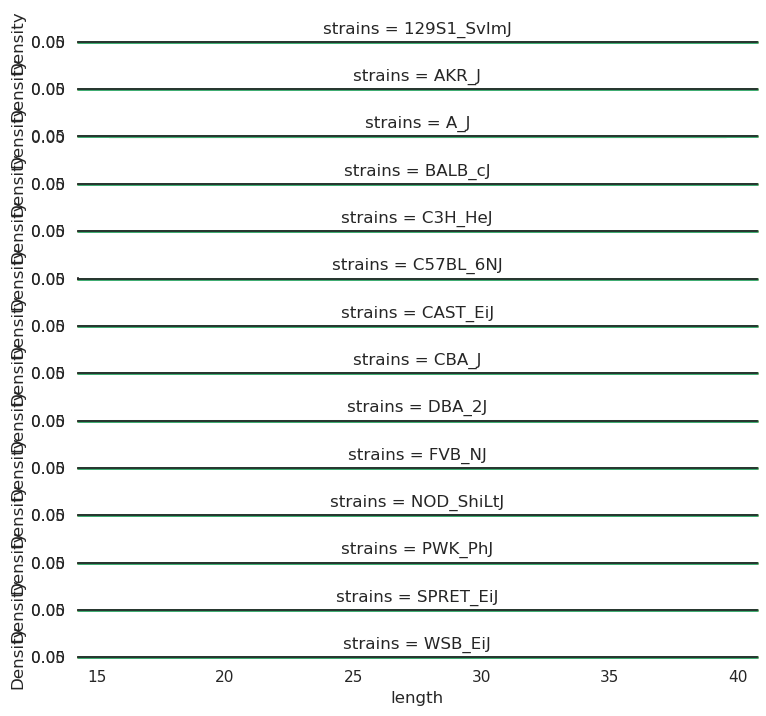

In [32]:
import seaborn as sns

# create the Ridgeline plot using seaborn
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_palette("husl")
g = sns.FacetGrid(df, row="strains", hue="timpepoint", aspect=15, height=0.5, palette=sns.color_palette("husl", 5))
g.map(sns.kdeplot, "length", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "length", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)
g.map(plt.xlabel, 'length')
g.fig.subplots_adjust(hspace=-0.3)
plt.show()


In [ ]:
plt.xlabel("length")
fig, axes = joypy.joyplot(df[df.collapsed  != 'aligned'], by="Year", column="Value",figsize=(5,8),
             linewidth=0.05,overlap=3,colormap=cm.summer_r,x_range=[0,110])

plt.text(40, 0.8, "Top 50 transfer values (€m) \n 1991-2017",fontsize=12)

plt.show()

In [ ]:
fig, axes = joypy.joyplot(df[df.Player != 'Neymar'],by="Year", column="Value", ylabels=False, xlabels=False, 
                          grid=False, fill=False, background='k', linecolor="w", linewidth=1, x_range=[-60,110],
                          legend=False, overlap=0.5, figsize=(6,5),kind="counts", bins=80)